# Exporting and sharing walkers

Once you have a walker — hand-designed, optimized by GA, or discovered
by the topology co-optimizer — you'll want to do four things with it:

1. **Save it** so you can reload it later or share it with collaborators.
2. **Export it to URDF** so it can be loaded by ROS, Gazebo, MoveIt, or
   any other robotics simulator that speaks the format.
3. **Snapshot it as SVG** for papers, slides, or the project README.
4. **View it interactively** with hover, zoom, and pan in a notebook or
   browser.

This notebook walks through each surface using ``Walker.from_jansen()``
as the working specimen. Every section runs in seconds.

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import leggedsnake as ls

walker = ls.Walker.from_jansen(scale=0.1)
print(walker)
print(f"  nodes: {len(walker.topology.nodes)}")
print(f"  edges: {len(walker.topology.edges)}")
print(f"  feet:  {walker.get_feet()}")

  nodes: 8
  edges: 11
  feet:  ['F', 'C', 'E', 'D', 'G']


## 1. JSON serialization

``save_walker`` / ``load_walker`` round-trip a walker through a JSON
file: topology + dimensions + motor rates. The on-disk format is
human-readable and version-controlled-friendly.

For programmatic use (sending walkers over a wire, embedding in a
larger document), ``walker_to_dict`` and ``walker_from_dict`` give you
the same data as a Python ``dict`` without touching the filesystem.

In [2]:
with tempfile.TemporaryDirectory() as tmp:
    out = Path(tmp) / "jansen.json"
    ls.save_walker(walker, out)
    print(f"Saved: {out.stat().st_size} bytes")

    loaded = ls.load_walker(out)
    print(f"Reloaded: {len(loaded.topology.nodes)} nodes, "
          f"{len(loaded.topology.edges)} edges")

    # Round-trip equivalence (topology + dimensions match)
    assert set(loaded.topology.nodes) == set(walker.topology.nodes)
    assert set(loaded.topology.edges) == set(walker.topology.edges)
    print("Round-trip OK")

Saved: 3096 bytes
Reloaded: 8 nodes, 11 edges
Round-trip OK


In [3]:
# Same data as a dict, no filesystem
d = ls.walker_to_dict(walker)
print(f"Top-level keys: {list(d.keys())}")
print(f"  topology: {len(d['topology']['nodes'])} nodes, "
      f"{len(d['topology']['edges'])} edges")
print(f"  dimensions: {len(d['dimensions']['node_positions'])} "
      f"node_positions, {len(d['dimensions']['edge_distances'])} "
      f"edge_distances")

Top-level keys: ['version', 'name', 'topology', 'dimensions', 'motor_rates']
  topology: 8 nodes, 11 edges
  dimensions: 8 node_positions, 11 edge_distances


## 2. URDF export for ROS

``to_urdf_file`` writes a URDF (Unified Robot Description Format) file
that loads in ROS, Gazebo, MoveIt, RViz, and most physics engines that
accept URDF. ``to_urdf`` returns the same content as a string when you
want to embed it in a launch file or send it over a topic.

``URDFConfig`` controls the rendering: link radius (cylinder thickness),
density (drives mass), effort/velocity limits per joint, and the
visual mesh colour.

In [4]:
config = ls.URDFConfig(
    link_radius=0.015,
    density=800.0,                # kg/m^3 — closer to wood than steel
    mesh_color=(0.2, 0.5, 0.9, 1.0),
)

with tempfile.TemporaryDirectory() as tmp:
    out = Path(tmp) / "jansen.urdf"
    ls.to_urdf_file(walker, str(out), config=config)
    text = out.read_text()
    print(f"URDF: {out.stat().st_size} bytes, "
          f"{text.count('<link')} <link>, "
          f"{text.count('<joint')} <joint>")
    # First few lines
    print()
    print("\n".join(text.splitlines()[:6]))

URDF: 10415 bytes, 12 <link>, 16 <joint>

<?xml version='1.0' encoding='utf-8'?>
<robot name="jansen">
  <link name="base_link">
    <inertial>
      <mass value="1.0" />
      <inertia ixx="0.001" iyy="0.001" izz="0.001" ixy="0" ixz="0" iyz="0" />


## 3. SVG snapshot

``save_walker_svg`` renders one full crank revolution and writes an SVG
showing the linkage outline plus each foot's locus. SVG is vector,
scales cleanly into papers and posters, and stays small even for
8-bar mechanisms.

SVG: 18277 bytes


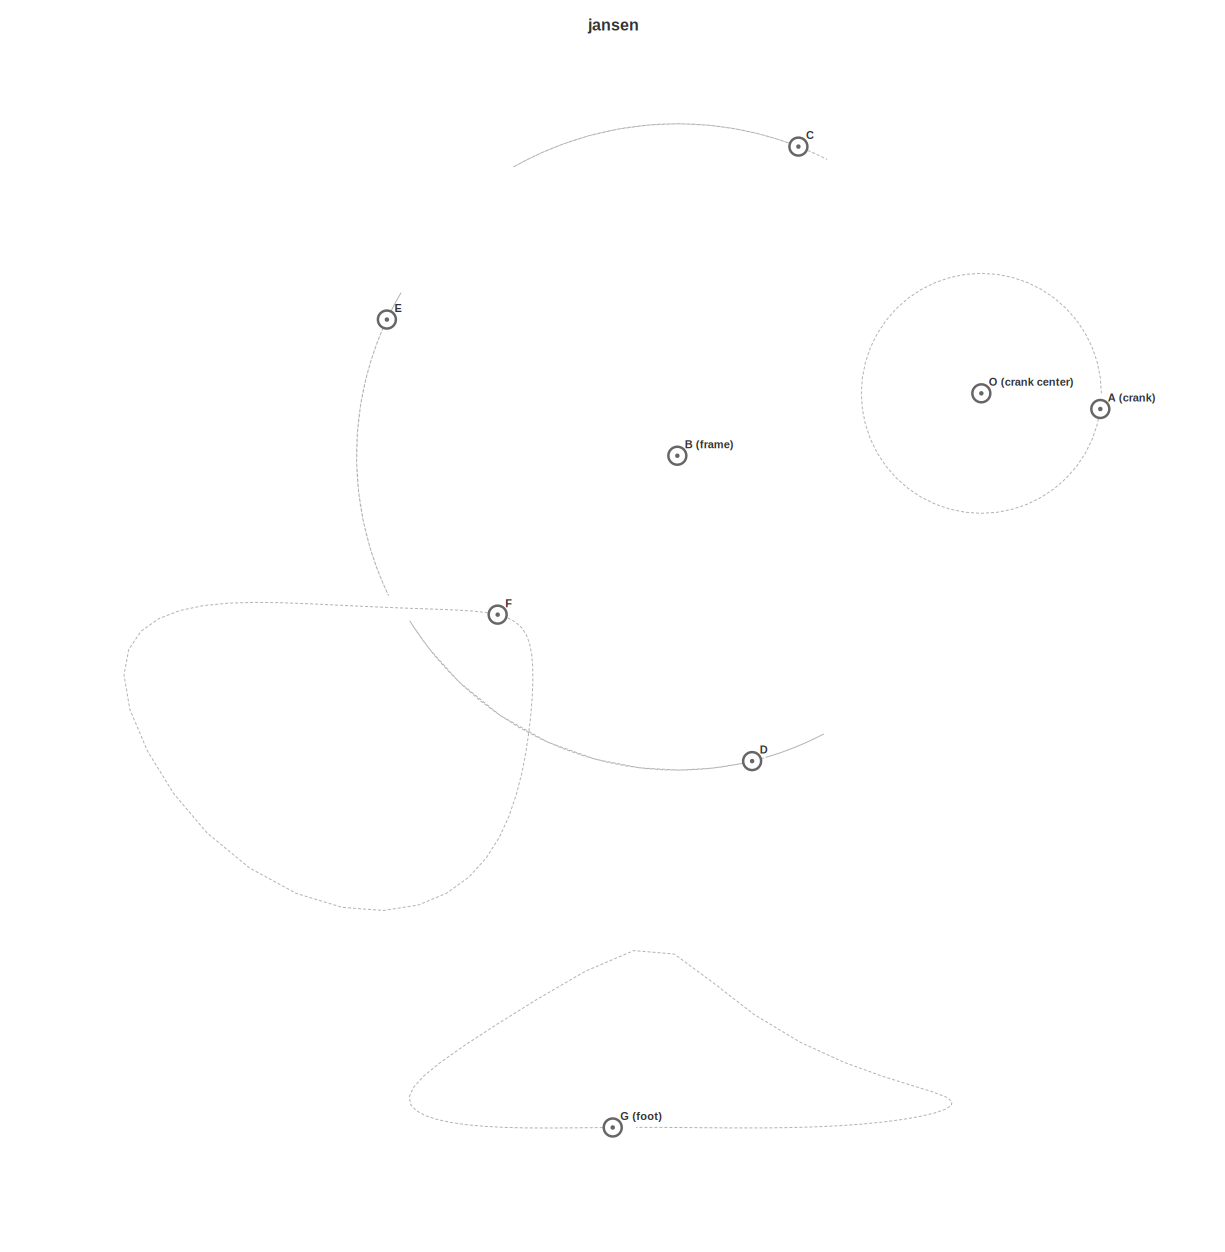

In [5]:
with tempfile.TemporaryDirectory() as tmp:
    out = Path(tmp) / "jansen.svg"
    ls.save_walker_svg(walker, str(out))
    raw = out.read_bytes()
    print(f"SVG: {len(raw)} bytes")
    # Embed in the notebook
    from IPython.display import SVG, display
    display(SVG(data=raw))

## 4. Interactive plotly visualization

``plot_walker_plotly`` returns a plotly ``Figure`` with the linkage,
foot loci, and joint labels. In a notebook you get hover, zoom, and
pan for free; ``fig.write_html(path)`` saves a self-contained
interactive page you can email or post.

In [6]:
fig = ls.plot_walker_plotly(
    walker,
    title="Theo Jansen leg — interactive",
    width=720,
    height=480,
)
fig.show()

## Where to next

- **Atlas of evolved walkers**: pair these I/O helpers with the Pareto
  fronts from notebook 04 to publish a browseable catalogue
  (per-solution SVG + interactive plotly + downloadable URDF).
- **Cross-tool pipeline**: drop the URDF into ROS / Gazebo for
  whole-body dynamics with contact and friction richer than pymunk's
  2D model.
- **Re-importing optimizer state**: ``save_result`` / ``load_result``
  do the same JSON round-trip for ``GeneticOptimizationResult`` if
  you want to ship full GA runs, not just final walkers.